### 1. Data Loading and Structure Exploration

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset 
df = pd.read_csv('Dataset .csv')

# 2. Identify rows and columns
rows, cols = df.shape
print(f"The dataset successfully loaded with {rows} rows and {cols} columns!\n")

# 3. View the first 5 rows of the data
print("First 5 rows of the dataset:")
print(df.head())

The dataset successfully loaded with 9551 rows and 21 columns!

First 5 rows of the dataset:
   Restaurant ID         Restaurant Name  Country Code              City  \
0        6317637        Le Petit Souffle           162       Makati City   
1        6304287        Izakaya Kikufuji           162       Makati City   
2        6300002  Heat - Edsa Shangri-La           162  Mandaluyong City   
3        6318506                    Ooma           162  Mandaluyong City   
4        6314302             Sambo Kojin           162  Mandaluyong City   

                                             Address  \
0  Third Floor, Century City Mall, Kalayaan Avenu...   
1  Little Tokyo, 2277 Chino Roces Avenue, Legaspi...   
2  Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...   
3  Third Floor, Mega Fashion Hall, SM Megamall, O...   
4  Third Floor, Mega Atrium, SM Megamall, Ortigas...   

                                     Locality  \
0   Century City Mall, Poblacion, Makati City   
1  Little Tokyo

### 2. Missing Values and Data Type Verification

In [3]:
# 1. Check for missing values in each column
print("Missing values per column:")
print(df.isnull().sum())

# 2. If 'Cuisines' has missing data, let's fill it with 'Unknown' so our data is complete
if df['Cuisines'].isnull().any():
    df['Cuisines'] = df['Cuisines'].fillna('Unknown')
    print("\nSuccessfully handled missing values in 'Cuisines' column!")

# 3. See basic statistics of the ratings (Mean, Max, Min)
print("\nRating Distribution Summary:")
print(df['Aggregate rating'].describe())

Missing values per column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Successfully handled missing values in 'Cuisines' column!

Rating Distribution Summary:
count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


### 3. Descriptive Analysis and Data Visualization

Mean (Average) Rating: 2.67
Median Rating: 3.20

Top 10 Most Common Cuisines:
Cuisines
North Indian                      936
North Indian, Chinese             511
Chinese                           354
Fast Food                         354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


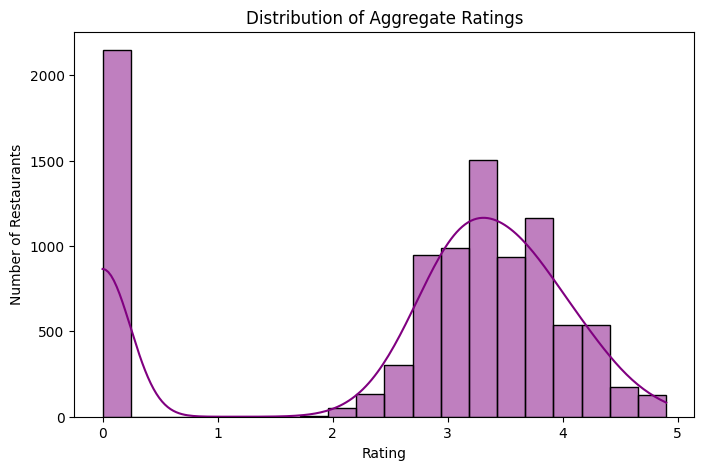

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the mean, median, and mode for numerical columns
mean_rating = df['Aggregate rating'].mean()
median_rating = df['Aggregate rating'].median()

print(f"Mean (Average) Rating: {mean_rating:.2f}")
print(f"Median Rating: {median_rating:.2f}")

# 2. Find the top 10 most common cuisines in the dataset
print("\nTop 10 Most Common Cuisines:")
print(df['Cuisines'].value_counts().head(10))

# 3. Create a graph showing the distribution of the ratings
plt.figure(figsize=(8, 5))
sns.histplot(df['Aggregate rating'], bins=20, kde=True, color='purple')
plt.title('Distribution of Aggregate Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Restaurants')

# Save the graph automatically to your project folder
plt.savefig('rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### 4. Geospatial Location Analysis

In [5]:
# 1. Identify the top 10 cities with the highest number of restaurants
print("Top 10 Cities with the Most Restaurants:")
print(df['City'].value_counts().head(10))

# 2. Calculate the average rating for each city to see if location matters
print("\nAverage Rating by City (Top 10):")
top_cities = df['City'].value_counts().head(10).index
print(df[df['City'].isin(top_cities)].groupby('City')['Aggregate rating'].mean().sort_values(ascending=False))

# 3. Optional: Check correlation between Latitude/Longitude and Rating
correlation = df[['Latitude', 'Longitude', 'Aggregate rating']].corr()
print("\nCorrelation matrix between Location Coordinates and Rating:")
print(correlation['Aggregate rating'])

Top 10 Cities with the Most Restaurants:
City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Ahmedabad         21
Amritsar          21
Bhubaneshwar      21
Guwahati          21
Lucknow           21
Name: count, dtype: int64

Average Rating by City (Top 10):
City
Lucknow         4.195238
Guwahati        4.190476
Ahmedabad       4.161905
Bhubaneshwar    3.980952
Amritsar        3.685714
Ghaziabad       2.852000
Gurgaon         2.651431
New Delhi       2.438845
Noida           2.036204
Faridabad       1.866932
Name: Aggregate rating, dtype: float64

Correlation matrix between Location Coordinates and Rating:
Latitude            0.000516
Longitude          -0.116818
Aggregate rating    1.000000
Name: Aggregate rating, dtype: float64
